# 출시 후 LLM 리뷰 분석 보고서: Tainted Grail: The Fall of Avalon

## 분석 목적
이미 출시된 게임의 Steam 리뷰와 LLM 분석 결과를 바탕으로,  
개발자가 **현재 유저들이 무엇을 좋아하고 무엇에 불만을 가지는지** 파악하고, **패치·운영 우선 검토 이슈**를 정리하는 것을 목적으로 한다.

## 핵심 질문
1. 현재 이 게임의 출시 후 반응은 긍정적인가, 부정적인가?
2. 유저들은 어떤 요소를 강점으로 보고 있는가?
3. 부정 리뷰에서는 어떤 문제가 반복적으로 나타나는가?
4. 어떤 문제를 먼저 확인해야 반응 개선 가능성이 높은가?
5. 운영·패치 방향을 어떻게 정리할 수 있는가?

## 사용 데이터
| 파일 | 역할 |
|---|---|
| `llm_review_analysis_result.csv` | 리뷰 1개 단위의 LLM 감성분석 결과 |
| `llm_issue_tags_flat.csv` | 리뷰 안에서 추출된 이슈 태그를 태그 단위로 펼친 결과 |

> 이 보고서는 단순히 감정 분포만 보는 것이 아니라, 리뷰에서 반복되는 원인과 개선 방향을 정리하여 출시 후 운영 판단에 연결하는 것을 목표로 한다.


In [1]:
# ============================================================
# 기본 라이브러리
# ============================================================
import os
import ast
import json
import time
import asyncio
import platform
from pathlib import Path
from typing import List, Literal, Optional
from datetime import datetime


# ============================================================
# 데이터 분석용 라이브러리
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ============================================================
# 한글 폰트 설정
# ============================================================
if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
elif platform.system() == "Darwin":  # macOS
    plt.rcParams["font.family"] = "AppleGothic"
else:  # Linux
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.figsize"] = (12, 6)

# pandas 출력 옵션
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)


# 1. 설정값

아래 설정값은 **Tainted Grail: The Fall of Avalon** 출시 후 분석용으로 맞춰둔 값이다.

다른 환경에서 실행할 경우 `ROOT`만 본인 프로젝트 경로에 맞게 수정하면 된다.  
LLM 분석 결과 파일은 `data/outputs/postlaunch_tainted_grail_v1` 폴더에 있다고 가정한다.


In [2]:
# ============================================================
# 1. 경로 설정
# ============================================================

# 프로젝트 루트 직접 지정
# 다른 환경에서 실행할 경우 ROOT만 본인 프로젝트 경로에 맞게 수정
ROOT = Path(r"C:\Users\joon5\Documents\github\steam-indie-game-analysis")

# LLM 분석 결과 폴더
RUN_NAME = "postlaunch_tainted_grail_v1"
OUTPUT_DIR = ROOT / "data" / "outputs" / RUN_NAME

# LLM 분석 산출물
RESULT_PATH = OUTPUT_DIR / "llm_review_analysis_result.csv"
TAG_PATH = OUTPUT_DIR / "llm_issue_tags_flat.csv"


print("ROOT 존재:", ROOT.exists())
print("LLM 감성분석 결과 존재:", RESULT_PATH.exists())
print("LLM 감성분석 태그 존재:", TAG_PATH.exists())

print("\n프로젝트 루트:", ROOT)
print("LLM 감성분석 결과 :", RESULT_PATH)
print("LLM 감성분석 태그:", TAG_PATH)

# ============================================================
# 1-1. 보고서 설정값
# ============================================================

# 분석 대상 게임
TARGET_APPID = 1466060
TARGET_GAME_NAME = "Tainted Grail: The Fall of Avalon"

# 여러 게임이 들어 있을 때 자동으로 리뷰 수가 가장 많은 게임을 선택할지 여부
# 현재 노트북은 Tainted Grail 전용이므로 False로 둔다.
AUTO_SELECT_IF_MULTIPLE_GAMES = False

# 보고서에 보여줄 상위 항목 수
TOP_N = 10

# 플레이타임 구간
# 0~1시간: 첫인상/초기 이탈
# 1~5시간: 초반 플레이 경험
# 5~20시간: 중반 플레이 경험
# 20시간 이상: 장기 플레이/누적 불만
PLAYTIME_BINS = [-0.001, 1, 5, 20, np.inf]
PLAYTIME_LABELS = ["0~1시간", "1~5시간", "5~20시간", "20시간 이상"]

# 출시 후 구간 정렬 기준
PERIOD_ORDER = ["D0-D7", "D8-D30", "D0-D30", "D31-D90", "D91-D180", "D181+"]


ROOT 존재: True
LLM 감성분석 결과 존재: True
LLM 감성분석 태그 존재: True

프로젝트 루트: C:\Users\joon5\Documents\github\steam-indie-game-analysis
LLM 감성분석 결과 : C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\postlaunch_tainted_grail_v1\llm_review_analysis_result.csv
LLM 감성분석 태그: C:\Users\joon5\Documents\github\steam-indie-game-analysis\data\outputs\postlaunch_tainted_grail_v1\llm_issue_tags_flat.csv


# 2. 데이터 불러오기 및 기본 점검

출시 후 분석에서 핵심이 되는 데이터는 두 가지다.

| 데이터 | 분석 관점 |
|---|---|
| 리뷰 단위 데이터 | 리뷰별 감정, 긴급도, 플레이타임, 출시 후 경과일 |
| 태그 단위 데이터 | 반복되는 칭찬 요인과 불만 요인 |


In [3]:
# ============================================================
# 2. 데이터 불러오기
# ============================================================

df_result_raw = pd.read_csv(RESULT_PATH)
df_tags_raw = pd.read_csv(TAG_PATH)

print("df_result_raw shape:", df_result_raw.shape)
print("df_tags_raw shape:", df_tags_raw.shape)

display(df_result_raw.head(3))
display(df_tags_raw.head(3))


df_result_raw shape: (999, 20)
df_tags_raw shape: (2225, 15)


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation
0,success,195635133,1466060,Tainted Grail: The Fall of Avalon,2025-05-25 15:43:07,2025-05-23,2.0,D0-D30,negative,6.333333,3.0,0.380041,negative,1.0,control,"[{'category': 'control', 'sentiment': 'negative', 'evidence': 'Parrying in this game is broken and untested.'}, {'ca...",high,패링 시스템의 불합리한 판정과 부족한 공격 신호로 인해 전투 경험이 매우 나쁨.,"패링 시스템의 판정 타이밍을 재검토하고, 적의 공격 전조(시각적/청각적 신호)를 명확하게 개선하여 플레이어가 반응할 수 있는 구조를 만드세요.",exact_match
1,success,217436457,1466060,Tainted Grail: The Fall of Avalon,2026-02-02 17:34:59,2025-05-23,255.0,D181+,positive,9.233333,0.0,0.500000,positive,4.0,story,"[{'category': 'bug', 'sentiment': 'negative', 'evidence': 'It still has some bugs.'}, {'category': 'crash', 'sentime...",medium,"버그와 크래시가 존재하지만, 뛰어난 스토리와 세계관 구현으로 충분히 가치 있는 게임.",현재 보고되는 간헐적인 크래시(CTD) 및 잔버그를 수정하여 전반적인 게임 안정성을 높이세요.,exact_match
2,success,218720038,1466060,Tainted Grail: The Fall of Avalon,2026-02-19 19:22:47,2025-05-23,272.0,D181+,positive,8.666667,0.0,0.500000,positive,4.0,gameplay_loop,"[{'category': 'gameplay_loop', 'sentiment': 'mixed', 'evidence': 'some things are jank, the game feels good and beli...",low,"약간의 투박함은 있으나 전투와 스킬 트리가 흥미로우며, 장비와 스탯 시스템의 개선을 희망함.",장비의 유연성을 높이고 스탯 포인트 배분 방식을 조정하여 플레이어의 빌드 선택 폭을 넓히는 것을 고려하세요.,exact_match


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence
0,195635133,1466060,Tainted Grail: The Fall of Avalon,negative,negative,control,high,D0-D30,6.333333,3.0,0.380041,control,조작감,negative,Parrying in this game is broken and untested.
1,195635133,1466060,Tainted Grail: The Fall of Avalon,negative,negative,control,high,D0-D30,6.333333,3.0,0.380041,graphics_audio,그래픽/사운드,negative,"No audio queues for attacks, visual queues are insufficient."
2,195635133,1466060,Tainted Grail: The Fall of Avalon,negative,negative,control,high,D0-D30,6.333333,3.0,0.380041,gameplay_loop,게임플레이 루프,negative,"Parrying is not skill-based, lacks proper design compared to genre standards."


In [4]:
# ============================================================
# 2-1. 필수 컬럼 확인
# ============================================================

required_result_cols = [
    "recommendationid",
    "appid",
    "game_name",
    "steam_label_text",
    "llm_sentiment",
    "urgency",
    "primary_issue",
    "summary",
    "suggested_action",
]

required_tag_cols = [
    "recommendationid",
    "appid",
    "game_name",
    "tag_category",
    "tag_sentiment",
    "tag_evidence",
]

missing_result_cols = [c for c in required_result_cols if c not in df_result_raw.columns]
missing_tag_cols = [c for c in required_tag_cols if c not in df_tags_raw.columns]

if missing_result_cols:
    raise ValueError(f"df_result에 필요한 컬럼이 없습니다: {missing_result_cols}")

if missing_tag_cols:
    raise ValueError(f"df_tags에 필요한 컬럼이 없습니다: {missing_tag_cols}")

print("필수 컬럼 확인 완료")


필수 컬럼 확인 완료


In [5]:
# ============================================================
# 2-2. 컬럼 표준화 및 파생 컬럼 생성
# ============================================================

df_result = df_result_raw.copy()
df_tags = df_tags_raw.copy()

# ID는 조인 안정성을 위해 문자열로 통일
df_result["recommendationid"] = df_result["recommendationid"].astype(str)
df_tags["recommendationid"] = df_tags["recommendationid"].astype(str)

# 날짜형 변환
for col in ["review_datetime", "release_date"]:
    if col in df_result.columns:
        df_result[col] = pd.to_datetime(df_result[col], errors="coerce")

# 출시 후 경과일 생성
if "days_from_release" not in df_result.columns or df_result["days_from_release"].isna().all():
    if {"review_datetime", "release_date"}.issubset(df_result.columns):
        df_result["days_from_release"] = (df_result["review_datetime"] - df_result["release_date"]).dt.days

# 출시 후 구간 생성
if "release_period" not in df_result.columns:
    df_result["release_period"] = pd.cut(
        df_result["days_from_release"],
        bins=[-1, 7, 30, 90, 180, np.inf],
        labels=["D0-D7", "D8-D30", "D31-D90", "D91-D180", "D181+"]
    ).astype("object")

# 텍스트 라벨 소문자 통일
for col in ["steam_label_text", "llm_sentiment", "urgency", "sentiment_relation"]:
    if col in df_result.columns:
        df_result[col] = df_result[col].astype(str).str.lower().str.strip()

for col in ["steam_label_text", "llm_sentiment", "urgency", "tag_sentiment", "release_period"]:
    if col in df_tags.columns:
        df_tags[col] = df_tags[col].astype(str).str.lower().str.strip()

# release_period는 대문자 형식 유지
if "release_period" in df_result.columns:
    df_result["release_period"] = df_result["release_period"].astype(str).str.upper()
if "release_period" in df_tags.columns:
    df_tags["release_period"] = df_tags["release_period"].astype(str).str.upper()

# 플레이타임 구간 생성
if "playtime_at_review_hours" in df_result.columns:
    df_result["playtime_bin"] = pd.cut(
        df_result["playtime_at_review_hours"],
        bins=PLAYTIME_BINS,
        labels=PLAYTIME_LABELS
    ).astype("object")
else:
    df_result["playtime_bin"] = "정보 없음"

if "playtime_at_review_hours" in df_tags.columns:
    df_tags["playtime_bin"] = pd.cut(
        df_tags["playtime_at_review_hours"],
        bins=PLAYTIME_BINS,
        labels=PLAYTIME_LABELS
    ).astype("object")
else:
    df_tags["playtime_bin"] = "정보 없음"

# 한국어 이슈명 보정
ISSUE_NAME_KOR = {
    "positive_praise": "긍정 칭찬",
    "gameplay_loop": "게임플레이 루프",
    "content_volume": "콘텐츠 분량",
    "control": "조작감",
    "difficulty": "난이도",
    "multiplayer_network": "멀티/네트워크",
    "ui_ux": "UI/UX",
    "bug": "버그",
    "balance": "밸런스",
    "price_value": "가격/가치",
    "crash": "크래시",
    "performance": "성능",
    "other": "기타",
    "graphics_audio": "그래픽/사운드",
    "translation_localization": "번역/현지화",
    "developer_communication": "개발사 소통",
    "progression_grind": "성장/반복 노가다",
    "story": "스토리",
    "optimization": "최적화",
    "monetization": "과금/수익화",
    "save_progression": "저장/진행",
}

if "issue_name_kor" not in df_tags.columns:
    df_tags["issue_name_kor"] = df_tags["tag_category"].map(ISSUE_NAME_KOR).fillna(df_tags["tag_category"])
else:
    df_tags["issue_name_kor"] = df_tags["issue_name_kor"].fillna(df_tags["tag_category"].map(ISSUE_NAME_KOR))

print("전처리 후 데이터 확인")
display(df_result.head(3))
display(df_tags.head(3))


전처리 후 데이터 확인


,analysis_status,recommendationid,appid,game_name,review_datetime,release_date,days_from_release,release_period,steam_label_text,playtime_at_review_hours,votes_up,weighted_vote_score,llm_sentiment,sentiment_score,primary_issue,issue_tags,urgency,summary,suggested_action,sentiment_relation,playtime_bin
0,success,195635133,1466060,Tainted Grail: The Fall of Avalon,2025-05-25 15:43:07,2025-05-23,2.0,D0-D30,negative,6.333333,3.0,0.380041,negative,1.0,control,"[{'category': 'control', 'sentiment': 'negative', 'evidence': 'Parrying in this game is broken and untested.'}, {'ca...",high,패링 시스템의 불합리한 판정과 부족한 공격 신호로 인해 전투 경험이 매우 나쁨.,"패링 시스템의 판정 타이밍을 재검토하고, 적의 공격 전조(시각적/청각적 신호)를 명확하게 개선하여 플레이어가 반응할 수 있는 구조를 만드세요.",exact_match,5~20시간
1,success,217436457,1466060,Tainted Grail: The Fall of Avalon,2026-02-02 17:34:59,2025-05-23,255.0,D181+,positive,9.233333,0.0,0.500000,positive,4.0,story,"[{'category': 'bug', 'sentiment': 'negative', 'evidence': 'It still has some bugs.'}, {'category': 'crash', 'sentime...",medium,"버그와 크래시가 존재하지만, 뛰어난 스토리와 세계관 구현으로 충분히 가치 있는 게임.",현재 보고되는 간헐적인 크래시(CTD) 및 잔버그를 수정하여 전반적인 게임 안정성을 높이세요.,exact_match,5~20시간
2,success,218720038,1466060,Tainted Grail: The Fall of Avalon,2026-02-19 19:22:47,2025-05-23,272.0,D181+,positive,8.666667,0.0,0.500000,positive,4.0,gameplay_loop,"[{'category': 'gameplay_loop', 'sentiment': 'mixed', 'evidence': 'some things are jank, the game feels good and beli...",low,"약간의 투박함은 있으나 전투와 스킬 트리가 흥미로우며, 장비와 스탯 시스템의 개선을 희망함.",장비의 유연성을 높이고 스탯 포인트 배분 방식을 조정하여 플레이어의 빌드 선택 폭을 넓히는 것을 고려하세요.,exact_match,5~20시간


,recommendationid,appid,game_name,steam_label_text,llm_sentiment,primary_issue,urgency,release_period,playtime_at_review_hours,votes_up,weighted_vote_score,tag_category,issue_name_kor,tag_sentiment,tag_evidence,playtime_bin
0,195635133,1466060,Tainted Grail: The Fall of Avalon,negative,negative,control,high,D0-D30,6.333333,3.0,0.380041,control,조작감,negative,Parrying in this game is broken and untested.,5~20시간
1,195635133,1466060,Tainted Grail: The Fall of Avalon,negative,negative,control,high,D0-D30,6.333333,3.0,0.380041,graphics_audio,그래픽/사운드,negative,"No audio queues for attacks, visual queues are insufficient.",5~20시간
2,195635133,1466060,Tainted Grail: The Fall of Avalon,negative,negative,control,high,D0-D30,6.333333,3.0,0.380041,gameplay_loop,게임플레이 루프,negative,"Parrying is not skill-based, lacks proper design compared to genre standards.",5~20시간


# 3. 분석 대상 게임 선택

출시 후 분석은 특정 게임의 운영 판단을 돕는 것이 목적이다.  
따라서 여러 게임이 섞여 있다면 한 게임을 선택해서 분석한다.


In [6]:
# ============================================================
# 3. 분석 대상 게임 선택
# ============================================================

game_counts = (
    df_result
    .groupby(["appid", "game_name"], dropna=False)
    .size()
    .reset_index(name="review_count")
    .sort_values("review_count", ascending=False)
)

print("현재 데이터에 포함된 게임 목록")
display(game_counts)

if TARGET_APPID is not None:
    df_game = df_result[df_result["appid"] == TARGET_APPID].copy()
    selected_reason = f"TARGET_APPID={TARGET_APPID} 기준 선택"
elif TARGET_GAME_NAME is not None:
    df_game = df_result[df_result["game_name"] == TARGET_GAME_NAME].copy()
    selected_reason = f"TARGET_GAME_NAME={TARGET_GAME_NAME} 기준 선택"
else:
    if df_result["appid"].nunique() == 1:
        df_game = df_result.copy()
        selected_reason = "데이터에 게임이 1개만 있어 자동 선택"
    elif AUTO_SELECT_IF_MULTIPLE_GAMES:
        selected_appid = game_counts.iloc[0]["appid"]
        selected_name = game_counts.iloc[0]["game_name"]
        df_game = df_result[df_result["appid"] == selected_appid].copy()
        selected_reason = f"여러 게임 중 리뷰 수가 가장 많은 게임 자동 선택: {selected_name}"
    else:
        raise ValueError("여러 게임이 있습니다. TARGET_APPID 또는 TARGET_GAME_NAME을 지정해 주세요.")

if df_game.empty:
    raise ValueError("선택된 게임 데이터가 없습니다. TARGET_APPID 또는 TARGET_GAME_NAME을 확인해 주세요.")

selected_appid = df_game["appid"].iloc[0]
selected_game_name = df_game["game_name"].iloc[0]

df_game_tags = df_tags[df_tags["appid"] == selected_appid].copy()

selected_game_info = pd.DataFrame({
    "항목": ["게임명", "appid", "선택 기준", "분석 리뷰 수", "분석 태그 수"],
    "값": [selected_game_name, selected_appid, selected_reason, f"{len(df_game):,}개", f"{len(df_game_tags):,}개"]
})

display(selected_game_info)


현재 데이터에 포함된 게임 목록


,appid,game_name,review_count
0,1466060,Tainted Grail: The Fall of Avalon,999


,항목,값
0,게임명,Tainted Grail: The Fall of Avalon
1,appid,1466060
2,선택 기준,TARGET_APPID=1466060 기준 선택
3,분석 리뷰 수,999개
4,분석 태그 수,"2,225개"


# 4. 출시 후 반응 기본 요약

이 단계에서는 현재 게임의 전체 반응 상태를 빠르게 확인한다.

핵심 지표는 다음과 같다.

| 지표 | 의미 |
|---|---|
| 분석 표본 내 Steam 라벨 긍정률 | LLM 분석에 사용된 리뷰 표본에서 Steam 추천 라벨이 positive인 비율 |
| LLM 긍정률 | 리뷰 본문에서 실제 긍정 표현이 얼마나 강한지 |
| LLM 부정+혼합 비율 | 추천 여부와 별개로 불만이나 아쉬움이 포함된 비율 |
| High urgency 비율 | 빠르게 대응해야 할 가능성이 높은 리뷰 비율 |
| 플레이타임 | 불만이 초반 이탈인지, 장기 플레이 후 누적 불만인지 판단 |


In [7]:
# ============================================================
# 4. 출시 후 반응 기본 요약
# ============================================================

def safe_rate(series, condition):
    if len(series) == 0:
        return np.nan
    return condition(series).mean()

def pct(value):
    if pd.isna(value):
        return "-"
    return f"{value * 100:.1f}%"

def num(value, digits=1):
    if pd.isna(value):
        return "-"
    return f"{value:.{digits}f}"

total_reviews = len(df_game)
steam_positive_rate = safe_rate(df_game["steam_label_text"], lambda s: s.eq("positive"))
llm_positive_rate = safe_rate(df_game["llm_sentiment"], lambda s: s.eq("positive"))
llm_negative_mixed_rate = safe_rate(df_game["llm_sentiment"], lambda s: s.isin(["negative", "mixed"]))
high_urgency_rate = safe_rate(df_game["urgency"], lambda s: s.eq("high"))

release_date = df_game["release_date"].dropna().min() if "release_date" in df_game.columns else pd.NaT
first_review_date = df_game["review_datetime"].dropna().min() if "review_datetime" in df_game.columns else pd.NaT
last_review_date = df_game["review_datetime"].dropna().max() if "review_datetime" in df_game.columns else pd.NaT

overview_table = pd.DataFrame({
    "항목": [
        "게임명",
        "appid",
        "출시일",
        "분석 리뷰 수",
        "분석 태그 수",
        "분석 표본 내 Steam 라벨 긍정률",
        "LLM 긍정률",
        "LLM 부정+혼합 비율",
        "High urgency 비율",
        "분석 리뷰 시작일",
        "분석 리뷰 종료일",
        "평균 플레이타임(리뷰 시점)",
        "중앙값 플레이타임(리뷰 시점)"
    ],
    "값": [
        selected_game_name,
        selected_appid,
        release_date.date() if pd.notna(release_date) else "-",
        f"{total_reviews:,}개",
        f"{len(df_game_tags):,}개",
        pct(steam_positive_rate),
        pct(llm_positive_rate),
        pct(llm_negative_mixed_rate),
        pct(high_urgency_rate),
        first_review_date.date() if pd.notna(first_review_date) else "-",
        last_review_date.date() if pd.notna(last_review_date) else "-",
        f"{num(df_game['playtime_at_review_hours'].mean())}시간" if "playtime_at_review_hours" in df_game.columns else "-",
        f"{num(df_game['playtime_at_review_hours'].median())}시간" if "playtime_at_review_hours" in df_game.columns else "-",
    ]
})

display(overview_table)


,항목,값
0,게임명,Tainted Grail: The Fall of Avalon
1,appid,1466060
2,출시일,2025-05-23
3,분석 리뷰 수,999개
4,분석 태그 수,"2,225개"
5,분석 표본 내 Steam 라벨 긍정률,30.0%
6,LLM 긍정률,27.9%
7,LLM 부정+혼합 비율,71.9%
8,High urgency 비율,45.2%
9,분석 리뷰 시작일,2023-06-18


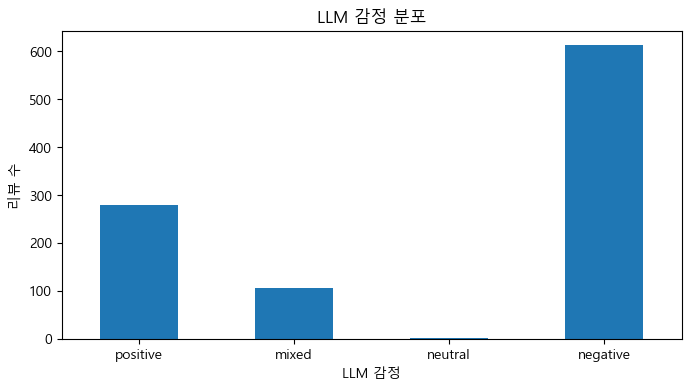

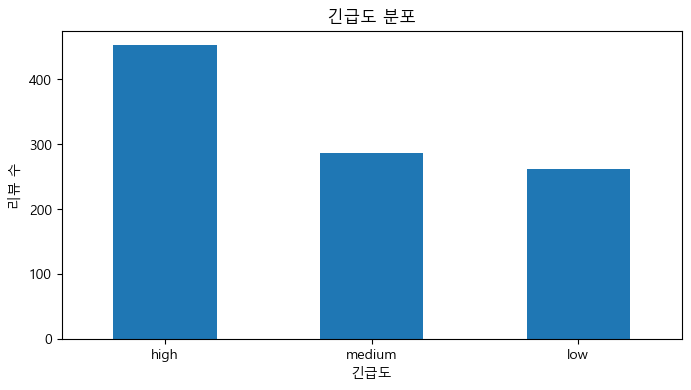

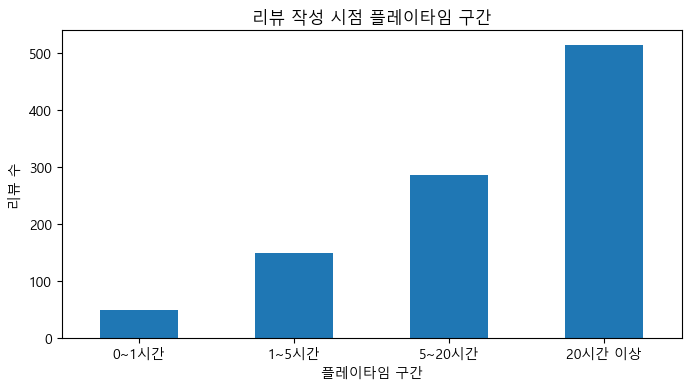

In [8]:
# ============================================================
# 4-1. 기본 분포 시각화
# ============================================================

if "llm_sentiment" in df_game.columns:
    sentiment_order = ["positive", "mixed", "neutral", "negative"]
    sentiment_counts = df_game["llm_sentiment"].value_counts().reindex(sentiment_order).dropna()

    ax = sentiment_counts.plot(kind="bar", figsize=(8, 4))
    ax.set_title("LLM 감정 분포")
    ax.set_xlabel("LLM 감정")
    ax.set_ylabel("리뷰 수")
    plt.xticks(rotation=0)
    plt.show()

if "urgency" in df_game.columns:
    urgency_order = ["high", "medium", "low"]
    urgency_counts = df_game["urgency"].value_counts().reindex(urgency_order).dropna()

    ax = urgency_counts.plot(kind="bar", figsize=(8, 4))
    ax.set_title("긴급도 분포")
    ax.set_xlabel("긴급도")
    ax.set_ylabel("리뷰 수")
    plt.xticks(rotation=0)
    plt.show()

if "playtime_bin" in df_game.columns:
    playtime_counts = df_game["playtime_bin"].value_counts().reindex(PLAYTIME_LABELS).dropna()

    ax = playtime_counts.plot(kind="bar", figsize=(8, 4))
    ax.set_title("리뷰 작성 시점 플레이타임 구간")
    ax.set_xlabel("플레이타임 구간")
    ax.set_ylabel("리뷰 수")
    plt.xticks(rotation=0)
    plt.show()


# 5. 출시 후 구간별 반응 변화

출시 후 분석에서는 단순 전체 평균보다 **시간에 따른 반응 변화**가 중요하다.

예를 들어 출시 초반에는 조작, 튜토리얼, 최적화 문제가 많이 나오고, 시간이 지난 뒤에는 콘텐츠 분량, 반복성, 밸런스 문제가 더 크게 나타날 수 있다.


,release_period,review_count,steam_positive_rate,llm_positive_rate,llm_negative_mixed_rate,high_urgency_rate,avg_playtime_hours,median_playtime_hours
0,D0-D30,388,0.311856,0.291237,0.708763,0.530928,26.340808,18.558333
2,D31-D90,118,0.288136,0.262712,0.737288,0.406780,47.218644,30.125000
3,D91-D180,89,0.258427,0.247191,0.752809,0.494382,33.100375,27.300000
1,D181+,398,0.306533,0.283920,0.711055,0.374372,28.842085,18.175000
4,PRE_RELEASE,6,0.000000,0.000000,1.000000,0.833333,79.719444,52.225000


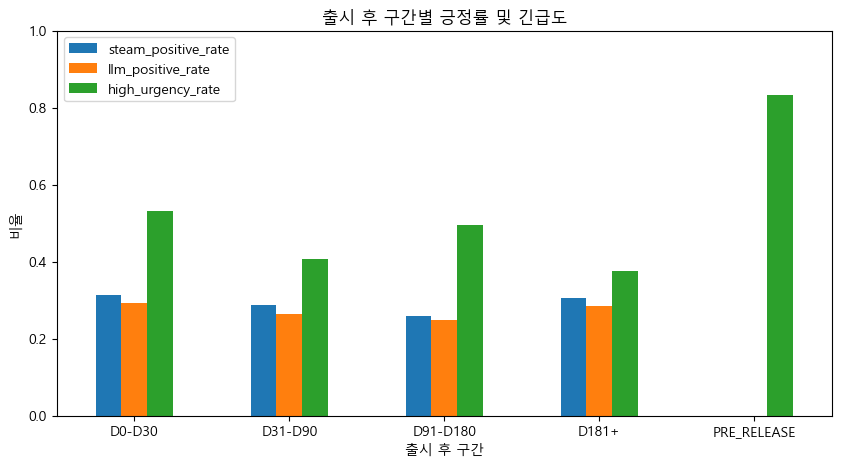

In [9]:
# ============================================================
# 5. 출시 후 구간별 반응 변화
# ============================================================

def sort_period_table(df, period_col="release_period"):
    result = df.copy()
    result["_period_order"] = result[period_col].apply(lambda x: PERIOD_ORDER.index(x) if x in PERIOD_ORDER else 999)
    result = result.sort_values(["_period_order", period_col]).drop(columns="_period_order")
    return result

period_summary = (
    df_game
    .groupby("release_period", dropna=False)
    .agg(
        review_count=("recommendationid", "count"),
        steam_positive_rate=("steam_label_text", lambda s: s.eq("positive").mean()),
        llm_positive_rate=("llm_sentiment", lambda s: s.eq("positive").mean()),
        llm_negative_mixed_rate=("llm_sentiment", lambda s: s.isin(["negative", "mixed"]).mean()),
        high_urgency_rate=("urgency", lambda s: s.eq("high").mean()),
        avg_playtime_hours=("playtime_at_review_hours", "mean"),
        median_playtime_hours=("playtime_at_review_hours", "median"),
    )
    .reset_index()
)

period_summary = sort_period_table(period_summary)

display(period_summary)

if not period_summary.empty:
    plot_df = period_summary.set_index("release_period")[["steam_positive_rate", "llm_positive_rate", "high_urgency_rate"]]

    ax = plot_df.plot(kind="bar", figsize=(10, 5))
    ax.set_title("출시 후 구간별 긍정률 및 긴급도")
    ax.set_xlabel("출시 후 구간")
    ax.set_ylabel("비율")
    plt.xticks(rotation=0)
    plt.ylim(0, 1)
    plt.show()


,days_from_release,review_count,steam_positive_rate,high_urgency_rate
0,-705,1,0.000000,0.000000
1,-684,1,0.000000,1.000000
2,-580,1,0.000000,1.000000
3,-571,1,0.000000,1.000000
4,-236,1,0.000000,1.000000
5,-50,1,0.000000,1.000000
6,0,7,0.571429,0.142857
7,1,27,0.333333,0.518519
8,2,28,0.321429,0.464286
9,3,25,0.320000,0.440000


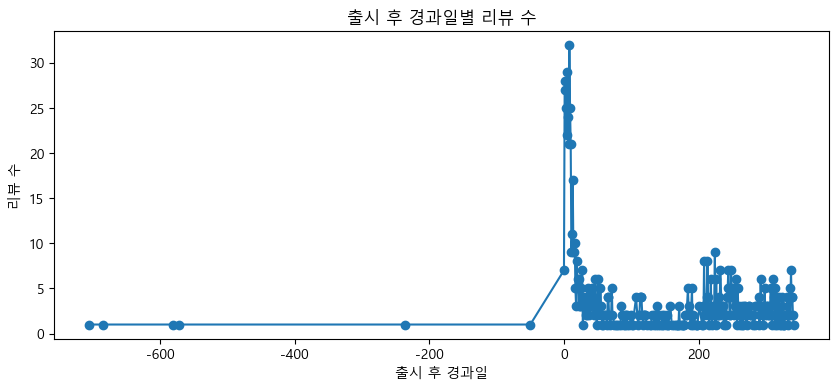

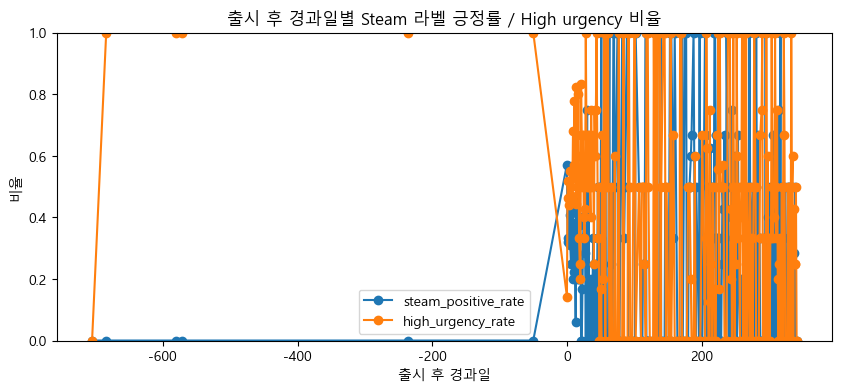

In [10]:
# ============================================================
# 5-1. 경과일별 리뷰 수와 반응 추세
# ============================================================

if "days_from_release" in df_game.columns and df_game["days_from_release"].notna().any():
    daily_summary = (
        df_game
        .dropna(subset=["days_from_release"])
        .assign(days_from_release=lambda d: d["days_from_release"].astype(int))
        .groupby("days_from_release")
        .agg(
            review_count=("recommendationid", "count"),
            steam_positive_rate=("steam_label_text", lambda s: s.eq("positive").mean()),
            high_urgency_rate=("urgency", lambda s: s.eq("high").mean()),
        )
        .reset_index()
        .sort_values("days_from_release")
    )

    display(daily_summary.head(30))

    if len(daily_summary) >= 2:
        ax = daily_summary.plot(
            x="days_from_release",
            y="review_count",
            kind="line",
            marker="o",
            figsize=(10, 4),
            legend=False
        )
        ax.set_title("출시 후 경과일별 리뷰 수")
        ax.set_xlabel("출시 후 경과일")
        ax.set_ylabel("리뷰 수")
        plt.show()

        ax = daily_summary.plot(
            x="days_from_release",
            y=["steam_positive_rate", "high_urgency_rate"],
            kind="line",
            marker="o",
            figsize=(10, 4)
        )
        ax.set_title("출시 후 경과일별 Steam 라벨 긍정률 / High urgency 비율")
        ax.set_xlabel("출시 후 경과일")
        ax.set_ylabel("비율")
        plt.ylim(0, 1)
        plt.show()
    else:
        print("경과일 종류가 1개라서 일자별 선 그래프는 생략합니다.")
else:
    print("days_from_release 컬럼이 없거나 비어 있어 경과일별 분석을 생략합니다.")


# 6. Steam 라벨과 LLM 감정 비교

Steam 추천/비추천 라벨과 LLM이 리뷰 본문에서 해석한 감정은 항상 일치하지 않는다.  
예를 들어 Steam에서는 추천 리뷰이지만, 본문에는 불편함이나 개선 요구가 함께 들어 있을 수 있다.

따라서 이 섹션에서는 Steam 라벨과 LLM 감정의 차이를 확인하여, 단순 추천 여부만으로 놓칠 수 있는 개선 요구를 살펴본다.


In [11]:
# ============================================================
# 6. Steam 라벨과 LLM 감정 비교
# ============================================================

steam_llm_crosstab = pd.crosstab(
    df_game["steam_label_text"],
    df_game["llm_sentiment"],
    margins=True
)

display(steam_llm_crosstab)

positive_but_not_positive = df_game[
    (df_game["steam_label_text"].eq("positive")) &
    (~df_game["llm_sentiment"].eq("positive"))
].copy()

negative_but_not_negative = df_game[
    (df_game["steam_label_text"].eq("negative")) &
    (~df_game["llm_sentiment"].eq("negative"))
].copy()

label_gap_summary = pd.DataFrame({
    "항목": [
        "Steam은 긍정이지만 LLM은 긍정이 아닌 리뷰",
        "Steam은 부정이지만 LLM은 부정이 아닌 리뷰",
    ],
    "리뷰 수": [
        len(positive_but_not_positive),
        len(negative_but_not_negative),
    ],
    "해석": [
        "게임을 추천하지만 불편함이나 개선 요구를 함께 말한 리뷰",
        "비추천이지만 일부 장점 또는 혼합 감정이 포함된 리뷰",
    ]
})

display(label_gap_summary)

review_cols = [
    "recommendationid",
    "review_datetime",
    "release_period",
    "playtime_at_review_hours",
    "steam_label_text",
    "llm_sentiment",
    "primary_issue",
    "urgency",
    "summary",
    "suggested_action",
]

print("Steam 긍정 리뷰 안의 개선 요구 예시")
display(positive_but_not_positive[[c for c in review_cols if c in positive_but_not_positive.columns]].head(10))


llm_sentiment,mixed,negative,neutral,positive,All
steam_label_text,,,,,
negative,86,612,1,0,699
positive,20,0,1,279,300
All,106,612,2,279,999


,항목,리뷰 수,해석
0,Steam은 긍정이지만 LLM은 긍정이 아닌 리뷰,21,게임을 추천하지만 불편함이나 개선 요구를 함께 말한 리뷰
1,Steam은 부정이지만 LLM은 부정이 아닌 리뷰,87,비추천이지만 일부 장점 또는 혼합 감정이 포함된 리뷰


Steam 긍정 리뷰 안의 개선 요구 예시


,recommendationid,review_datetime,release_period,playtime_at_review_hours,steam_label_text,llm_sentiment,primary_issue,urgency,summary,suggested_action
51,218263552,2026-02-14 02:05:36,D181+,100.683333,positive,mixed,balance,medium,초반은 매우 즐겁지만 후반부로 갈수록 밸런스 붕괴와 콘텐츠 부족(재탕된 모델)이 두드러짐.,"후반부 난이도 곡선을 재조정하고, 마지막 지역의 적과 보스 모델링을 다양화하여 콘텐츠 완성도를 높일 필요가 있음."
102,221718862,2026-03-26 04:44:58,D181+,2.000000,positive,neutral,other,low,"게임이 나쁘지는 않지만, 10년 전 게임 같은 느낌이며 특별한 매력이 부족함.","현재 게임의 핵심 차별화 요소가 부족하다는 의견이 있으므로, 현대적인 RPG 트렌드에 맞춘 시스템 개선이나 콘텐츠 보강을 고려하십시오."
145,215806208,2026-01-12 06:43:55,D181+,0.333333,positive,mixed,ui_ux,medium,게임 자체는 좋으나 현대적인 편의성 개선이 부족하고 과거의 불편한 게임 방식을 답습하고 있다는 비판입니다.,현대적인 게임 편의성(QoL) 개선 사항을 검토하여 사용자 경험을 최적화할 필요가 있습니다.
190,196642207,2025-06-07 17:45:49,D0-D30,59.233333,positive,mixed,balance,medium,"게임과 아트 스타일은 훌륭하나, 스킬 포인트 획득 제한으로 인해 장비 착용이 지나치게 제한되는 밸런스 문제를 지적함.",레벨업 당 스킬 포인트 획득량 조정이나 장비의 요구 능력치 제한 완화를 통해 캐릭터 빌드 자유도를 개선하는 밸런스 패치를 검토하십시오.
222,198764068,2025-07-02 19:07:18,D31-D90,110.083333,positive,mixed,story,medium,"전반적인 세계관과 게임플레이는 훌륭하나, 후반부 스토리의 완성도가 떨어지고 버그가 존재함.","Act 3의 서사적 개연성을 보완하고, 누락된 음성 대사 및 플레이스홀더 콘텐츠를 수정하여 후반부 몰입감을 개선할 필요가 있음."
451,195847371,2025-05-28 19:43:28,D0-D30,175.283333,positive,mixed,content_volume,medium,"전반적으로 재미있는 게임이나, 후반부(Act 3)의 콘텐츠 부족과 특정 직업군 아이템 밸런스 문제가 아쉬움.","Act 3의 콘텐츠 완성도를 높이고(보이스오버 추가, 퀘스트 개선), 도적 직업군을 위한 전용 장비 및 아이템 보상을 추가하여 밸런스를 조정하십시오."
456,196029517,2025-05-31 01:10:44,D0-D30,13.433333,positive,mixed,progression_grind,medium,"게임의 분위기와 스토리는 훌륭하나, 캐릭터 성장 속도가 너무 느리고 초반 난이도가 다소 높게 느껴짐.","초반 캐릭터 성장 체감을 개선하기 위해 레벨업 시 스탯 포인트 배분량을 조정하거나, 스킬 숙련도 상승에 따른 실질적인 이점을 명확하게 시각화하는 업데이트를 고려하십시오."
537,214904266,2026-01-02 10:18:21,D181+,68.983333,positive,mixed,control,high,"세계관과 몰입감은 훌륭하나, 조작감과 히트박스 문제, 초반 난이도 밸런스로 인해 전투 경험이 매우 나쁨.",전투 판정(히트박스) 최적화 및 조작감 개선이 시급합니다. 초반 난이도 곡선을 조정하여 플레이어가 불합리함을 느끼지 않도록 밸런스 패치를 고려하세요.
574,209976721,2025-11-24 00:04:14,D181+,18.716667,positive,mixed,content_volume,medium,세계관과 콘텐츠 양은 좋으나 사이드 퀘스트가 지나치게 단순하고 가격 대비 완성도가 아쉬움.,"사이드 퀘스트의 질적 개선이 필요합니다. 양적인 콘텐츠보다는 핵심 퀘스트의 깊이를 더하고, 제작 및 퍽 시스템의 완성도를 높이는 방향으로 업데이트를 진행하세요."
632,196277587,2025-06-02 23:34:24,D0-D30,42.166667,positive,mixed,balance,high,"전반적으로 좋은 게임이나, 중후반부 적들의 과도한 체력(데미지 스펀지)과 스킬 트리 관련 버그 및 설명 부족이 게임 경험을 저해함.","중후반부 적의 체력 밸런스를 재조정하고, 스킬 트리 내 버그 수정 및 스킬 설명의 가독성을 개선하여 플레이어가 더 명확한 선택을 할 수 있도록 지원하세요."


# 7. 유저가 좋아한 요소 분석

이 섹션에서는 유저가 긍정적으로 언급한 요소를 확인한다.  
단, `positive_praise`는 “재밌다”, “좋다”처럼 전반적 만족 표현에 가까워 구체적인 운영 전략으로 연결하기 어렵다.

따라서 강점 분석에서는 `positive_praise`를 제외하고, 그래픽/사운드, 콘텐츠, 조작감, 난이도처럼 실제 유지·강화 전략으로 연결 가능한 태그를 중심으로 확인한다.


,항목,값
0,positive_praise 제외 리뷰 수,341
1,positive_praise 제외 태그 수,342


,tag_category,issue_name_kor,positive_tag_count,affected_review_count,avg_playtime_hours,median_playtime_hours,representative_evidence
11,story,스토리,62,62,35.247312,25.866667,"stories, voice acting, conversations are all incredible. / Main story is unique and interesting but not enough of it..."
5,gameplay_loop,게임플레이 루프,45,44,42.404444,35.433333,gameplay and crafting are phenomenal / gameplay and economy and RPG systems were very good / It's like Skyrim... sti...
6,graphics_audio,그래픽/사운드,30,30,39.980000,17.016667,"voice acting so far is amazing, setting is creepy / cool skal music / graphics are good and somewhat stylized, music..."
2,content_volume,콘텐츠 분량,8,8,36.568750,43.208333,"decent first act and engaging quests / They do not prolong the game, they ARE the game! / 50hrs in and I have only j..."
3,developer_communication,개발사 소통,5,5,53.860000,41.450000,Updates and fixes are coming quick / devs are great at communicating and very receptive / in game Bug report if you ...
4,difficulty,난이도,5,5,38.600000,30.483333,difficulty spike is quite heavy between the maps and motivates the player to explore / difficulty level can be broug...
10,price_value,가격/가치,4,4,46.770833,34.375000,worth it on sale for sure / Game is worth Full Price / For the price point I think it's fantastic especially with th...
1,bug,버그,3,3,58.588889,43.766667,"rumored bugs seems to be patched, no crashes / there are bug but full of Proud devs who are working on all of them /..."
9,performance,성능,3,3,11.555556,6.116667,"runs well and feels very smooth / performance is great / staying damn near locked to 120 fps, with drops in the worl..."
12,ui_ux,UI/UX,3,3,44.527778,18.483333,"quality of life features like transmog, unstuck menu, campfire are great / it lets you pick 'Male' & 'Female' (Not j..."


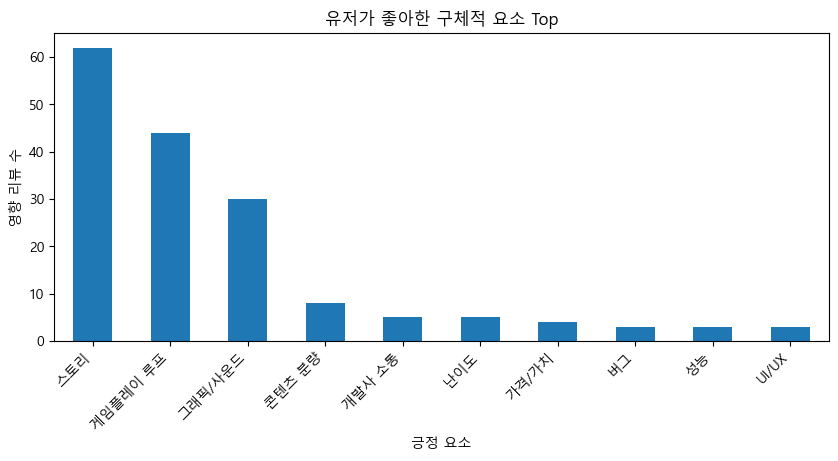

In [12]:
# ============================================================
# 7. 긍정 강점 분석
# ============================================================

pos_tags_all = df_game_tags[df_game_tags["tag_sentiment"].eq("positive")].copy()
positive_praise_tags = pos_tags_all[pos_tags_all["tag_category"].eq("positive_praise")].copy()

# positive_praise는 전반적 만족 표현이므로 구체적 강점 분석에서는 제외
pos_tags = pos_tags_all[~pos_tags_all["tag_category"].eq("positive_praise")].copy()

positive_praise_overview = pd.DataFrame({
    "항목": ["positive_praise 제외 리뷰 수", "positive_praise 제외 태그 수"],
    "값": [positive_praise_tags["recommendationid"].nunique(), len(positive_praise_tags)]
})

display(positive_praise_overview)

if pos_tags.empty:
    positive_strength_summary = pd.DataFrame()
    print("positive_praise를 제외하면 구체적인 긍정 태그가 없습니다.")
else:
    positive_strength_summary = (
        pos_tags
        .groupby(["tag_category", "issue_name_kor"], dropna=False)
        .agg(
            positive_tag_count=("tag_category", "count"),
            affected_review_count=("recommendationid", "nunique"),
            avg_playtime_hours=("playtime_at_review_hours", "mean"),
            median_playtime_hours=("playtime_at_review_hours", "median"),
            representative_evidence=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(3))),
        )
        .reset_index()
        .sort_values(["affected_review_count", "positive_tag_count"], ascending=False)
    )

    display(positive_strength_summary.head(TOP_N))

    ax = positive_strength_summary.head(TOP_N).set_index("issue_name_kor")["affected_review_count"].plot(
        kind="bar",
        figsize=(10, 4)
    )
    ax.set_title("유저가 좋아한 구체적 요소 Top")
    ax.set_xlabel("긍정 요소")
    ax.set_ylabel("영향 리뷰 수")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# 8. 유저가 불만을 가진 요소 분석

출시 후 분석의 핵심은 **부정 리뷰에서 반복되는 문제를 찾는 것**이다.

여기서는 부정 태그를 기준으로 다음을 함께 확인한다.

| 항목 | 의미 |
|---|---|
| 부정 태그 수 | 해당 이슈가 얼마나 자주 언급되었는지 |
| 영향 리뷰 수 | 몇 개의 리뷰에서 이 문제가 나타났는지 |
| High urgency 리뷰 수 | 빠른 대응이 필요한 리뷰가 얼마나 있는지 |
| 평균 플레이타임 | 초반 이탈 문제인지, 누적 불만인지 |
| 대표 근거 | 실제 리뷰에서 나온 표현 |


,tag_category,issue_name_kor,negative_tag_count,affected_review_count,high_urgency_review_count,medium_urgency_review_count,short_exit_review_count,avg_playtime_hours,median_playtime_hours,total_votes_up,representative_evidence
7,gameplay_loop,게임플레이 루프,294,277,159,125,18,22.823413,13.941667,2173.0,"Parrying is not skill-based, lacks proper design compared to genre standards. / Animations and combat are poor and h..."
1,bug,버그,238,237,191,38,7,40.625560,30.583333,885.0,It still has some bugs. / quest bricking / fair share of bugs
0,balance,밸런스,155,152,95,58,3,36.217312,24.083333,1885.0,"I hate level scaling / enemies that two shot me, taking me about 30 hits to kill them, 5 of them at once / Either th..."
17,story,스토리,140,139,67,66,3,35.221786,26.633333,762.0,majority of the NPCs have way too much dialogue about nothing of interest / story was not enticing at all and felt p...
8,graphics_audio,그래픽/사운드,124,121,67,49,11,24.082258,13.991667,309.0,"No audio queues for attacks, visual queues are insufficient. / no voice sync / art style seems very basic, monsters/..."
13,performance,성능,95,95,85,10,7,21.491579,13.183333,220.0,"frame rates tanks in the later acts / FPS varies from 120+ to below 60, performance is incredibly unstable / not wel..."
12,other,기타,96,95,26,45,6,26.870486,21.550000,393.0,"Seems unacceptable quality for 2025. / janky and indie, collection of memes, accidentally comical meta-game design /..."
2,content_volume,콘텐츠 분량,86,86,58,21,1,46.253101,38.933333,439.0,side quest are boring and seems forgotten / Side quests are mostly a miss and don't add much to the world. / Quests ...
19,ui_ux,UI/UX,71,71,33,36,8,26.375117,13.750000,170.0,"HUD, inventory is a mess / map not showing cleared dungeons as cleared / all around a bit clunky"
3,control,조작감,65,64,52,13,11,17.927949,6.383333,181.0,"Parrying in this game is broken and untested. / strafe speed is lower than forward movement speed, feels clunky / fo..."


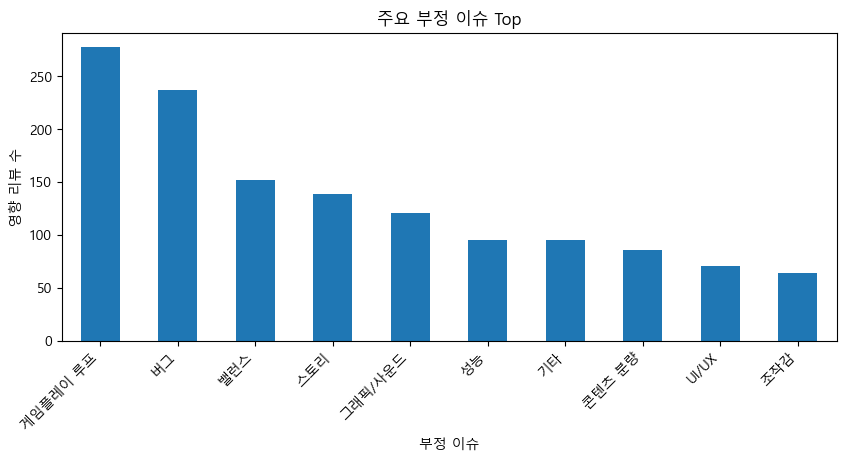

In [13]:
# ============================================================
# 8. 부정 이슈 분석
# ============================================================

neg_tags = df_game_tags[df_game_tags["tag_sentiment"].eq("negative")].copy()

if neg_tags.empty:
    negative_issue_summary = pd.DataFrame()
    print("부정 태그가 없습니다.")
else:
    negative_issue_summary = (
        neg_tags
        .groupby(["tag_category", "issue_name_kor"], dropna=False)
        .agg(
            negative_tag_count=("tag_category", "count"),
            affected_review_count=("recommendationid", "nunique"),
            high_urgency_review_count=("urgency", lambda s: s.eq("high").sum()),
            medium_urgency_review_count=("urgency", lambda s: s.eq("medium").sum()),
            short_exit_review_count=("playtime_bin", lambda s: s.eq("0~1시간").sum()),
            avg_playtime_hours=("playtime_at_review_hours", "mean"),
            median_playtime_hours=("playtime_at_review_hours", "median"),
            total_votes_up=("votes_up", "sum") if "votes_up" in neg_tags.columns else ("recommendationid", "count"),
            representative_evidence=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(3))),
        )
        .reset_index()
    )

    negative_issue_summary = negative_issue_summary.sort_values(
        ["affected_review_count", "high_urgency_review_count", "negative_tag_count"],
        ascending=False
    )

    display(negative_issue_summary.head(TOP_N))

    ax = negative_issue_summary.head(TOP_N).set_index("issue_name_kor")["affected_review_count"].plot(
        kind="bar",
        figsize=(10, 4)
    )
    ax.set_title("주요 부정 이슈 Top")
    ax.set_xlabel("부정 이슈")
    ax.set_ylabel("영향 리뷰 수")
    plt.xticks(rotation=45, ha="right")
    plt.show()


# 9. 플레이타임별 부정 원인

같은 부정 리뷰라도 플레이타임에 따라 의미가 다르다.

| 플레이타임 | 해석 |
|---|---|
| 0~1시간 | 첫인상, 튜토리얼, 조작, 최적화, 기대 불일치 문제 |
| 1~5시간 | 초반 플레이 경험, 반복성, 난이도, 진행 문제 |
| 5~20시간 | 중반 콘텐츠, 밸런스, 피로도, 버그 누적 |
| 20시간 이상 | 장기 플레이 유저의 후반 콘텐츠, 운영, 업데이트 불만 |


issue_name_kor,게임플레이 루프,버그,밸런스,스토리,그래픽/사운드,기타,성능,콘텐츠 분량,UI/UX,조작감
playtime_bin,,,,,,,,,,
0~1시간,18,7,3,3,11,6,7,1,8,11
1~5시간,57,19,10,19,30,15,27,0,10,17
5~20시간,97,54,53,37,30,25,28,17,24,18
20시간 이상,122,158,89,81,53,50,33,68,29,19


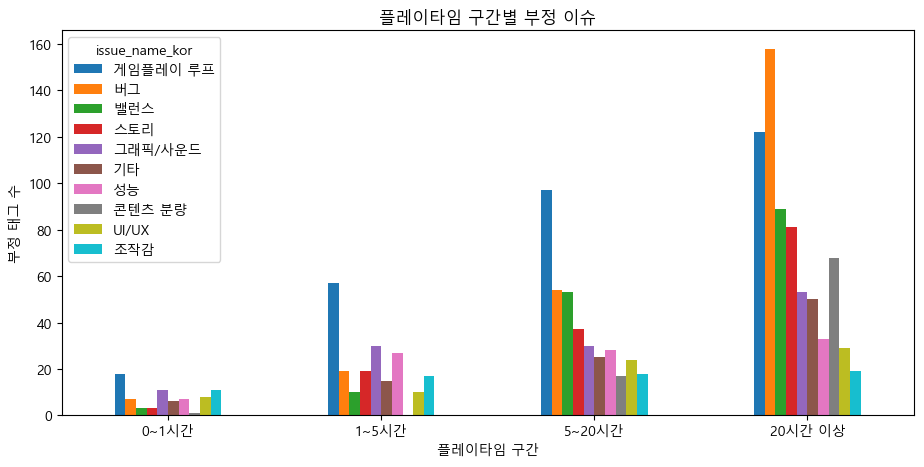

In [14]:
# ============================================================
# 9. 플레이타임별 부정 원인
# ============================================================

if neg_tags.empty:
    playtime_issue_table = pd.DataFrame()
    print("부정 태그가 없어 플레이타임별 부정 원인 분석을 생략합니다.")
else:
    playtime_issue_table = pd.crosstab(
        neg_tags["playtime_bin"],
        neg_tags["issue_name_kor"]
    )

    # 전체 빈도가 높은 이슈만 보기 좋게 정렬
    top_issue_cols = playtime_issue_table.sum(axis=0).sort_values(ascending=False).head(TOP_N).index
    playtime_issue_table = playtime_issue_table.reindex(PLAYTIME_LABELS).fillna(0)
    playtime_issue_table = playtime_issue_table[top_issue_cols]

    display(playtime_issue_table)

    ax = playtime_issue_table.plot(kind="bar", figsize=(11, 5))
    ax.set_title("플레이타임 구간별 부정 이슈")
    ax.set_xlabel("플레이타임 구간")
    ax.set_ylabel("부정 태그 수")
    plt.xticks(rotation=0)
    plt.show()


# 10. 패치·운영 우선 검토 이슈

출시 후 분석의 최종 목적은 리뷰에서 반복적으로 나타난 문제를 정리하고, 개발사가 어떤 이슈를 먼저 확인해야 하는지 판단할 수 있도록 돕는 것이다.

본 보고서에서는 임의의 종합 점수를 만들지 않고, 다음 기준을 나누어 확인한다.

1. 여러 리뷰에서 반복적으로 언급된 이슈
2. LLM이 High urgency로 분류한 리뷰가 많은 이슈
3. 0~1시간 플레이타임 구간에서 나타난 초기 이탈 관련 이슈
4. 출시 초반 구간에서 집중적으로 나타난 이슈

긴급도는 별도 수식으로 계산한 값이 아니라, LLM이 리뷰 본문을 읽고 분류한 값이다.  
따라서 High urgency 비율은 절대적인 장애 지표가 아니라, 유저가 느낀 문제의 심각도를 비교하기 위한 보조 기준으로 해석한다.

| 긴급도 | 해석 |
|---|---|
| high | 게임 진행 방해, 반복적 버그, 저장 문제, 심각한 불편처럼 빠른 확인이 필요한 문제 |
| medium | 불편함은 있으나 즉시 치명적이라고 보기는 어려운 문제 |
| low | 취향 차이, 가벼운 개선 요청, 단순 아쉬움에 가까운 문제 |


In [15]:
# ============================================================
# 10. 패치·운영 우선 검토 이슈
# ============================================================

# 패치·운영 검토는 전체 태그 중에서
# 1) 부정 태그이거나
# 2) LLM 감정이 negative/mixed이거나
# 3) urgency가 high인 태그를 중심으로 확인한다.
# 단, positive_praise는 전반적 만족 표현이므로 패치 대상 이슈에서는 제외한다.

priority_base = df_game_tags.copy()

if priority_base.empty:
    issue_priority_summary = pd.DataFrame()
    issue_action_summary = pd.DataFrame()
    issue_priority_with_action = pd.DataFrame()
    patch_priority = pd.DataFrame()
    operation_suggestion_table = pd.DataFrame()
    top_issue_evidence = pd.DataFrame()
    print("분석할 이슈 태그가 없어 패치·운영 우선 검토 이슈 분석을 생략합니다.")
else:
    # ------------------------------------------------------------
    # 1) 분석용 플래그 생성
    # ------------------------------------------------------------
    priority_base["urgency"] = priority_base["urgency"].astype(str).str.lower().str.strip()
    priority_base["llm_sentiment"] = priority_base["llm_sentiment"].astype(str).str.lower().str.strip()
    priority_base["tag_sentiment"] = priority_base["tag_sentiment"].astype(str).str.lower().str.strip()
    priority_base["release_period"] = priority_base["release_period"].astype(str).str.upper().str.strip()

    priority_base["is_negative_tag"] = priority_base["tag_sentiment"].eq("negative")
    priority_base["is_negative_or_mixed_review"] = priority_base["llm_sentiment"].isin(["negative", "mixed"])
    priority_base["is_high_urgency"] = priority_base["urgency"].eq("high")
    priority_base["is_initial_period"] = priority_base["release_period"].isin(["D0-D7", "D8-D30", "D0-D30"])

    if "playtime_at_review_hours" in priority_base.columns:
        priority_base["is_early_exit"] = priority_base["playtime_at_review_hours"].le(1)
    else:
        priority_base["is_early_exit"] = False

    # 조건별 리뷰 수를 중복 없이 세기 위한 보조 컬럼
    priority_base["high_urgency_review_id"] = priority_base["recommendationid"].where(priority_base["is_high_urgency"])
    priority_base["early_exit_review_id"] = priority_base["recommendationid"].where(priority_base["is_early_exit"])
    priority_base["initial_period_review_id"] = priority_base["recommendationid"].where(priority_base["is_initial_period"])
    priority_base["negative_or_mixed_review_id"] = priority_base["recommendationid"].where(priority_base["is_negative_or_mixed_review"])

    # 패치·운영 검토 대상만 필터링
    patch_focus_tags = priority_base[
        (
            priority_base["is_negative_tag"]
            | priority_base["is_negative_or_mixed_review"]
            | priority_base["is_high_urgency"]
        )
        & (~priority_base["tag_category"].eq("positive_praise"))
    ].copy()

    if patch_focus_tags.empty:
        issue_priority_summary = pd.DataFrame()
        issue_action_summary = pd.DataFrame()
        issue_priority_with_action = pd.DataFrame()
        patch_priority = pd.DataFrame()
        operation_suggestion_table = pd.DataFrame()
        top_issue_evidence = pd.DataFrame()
        print("패치·운영 우선 검토 대상으로 볼 부정/혼합/High urgency 이슈가 없습니다.")
    else:
        # ------------------------------------------------------------
        # 2) 이슈별 반복성·긴급성·초기 이탈·출시 초반 집중도 집계
        # ------------------------------------------------------------
        issue_priority_summary = (
            patch_focus_tags
            .groupby(["tag_category", "issue_name_kor"], dropna=False)
            .agg(
                영향_리뷰_수=("recommendationid", "nunique"),
                이슈_태그_수=("tag_category", "size"),
                부정_태그_수=("is_negative_tag", "sum"),
                부정_혼합_리뷰_수=("negative_or_mixed_review_id", "nunique"),
                High_urgency_리뷰_수=("high_urgency_review_id", "nunique"),
                초기_이탈_리뷰_수=("early_exit_review_id", "nunique"),
                출시초기_리뷰_수=("initial_period_review_id", "nunique"),
                평균_플레이타임=("playtime_at_review_hours", "mean"),
                중앙값_플레이타임=("playtime_at_review_hours", "median"),
                유용함_투표_합계=("votes_up", "sum"),
                대표_근거=("tag_evidence", lambda s: " / ".join(s.dropna().astype(str).head(3))),
            )
            .reset_index()
        )

        issue_priority_summary["High_urgency_비율"] = (
            issue_priority_summary["High_urgency_리뷰_수"]
            / issue_priority_summary["영향_리뷰_수"]
            * 100
        ).round(1)

        issue_priority_summary["초기_이탈_비율"] = (
            issue_priority_summary["초기_이탈_리뷰_수"]
            / issue_priority_summary["영향_리뷰_수"]
            * 100
        ).round(1)

        issue_priority_summary["출시초기_비율"] = (
            issue_priority_summary["출시초기_리뷰_수"]
            / issue_priority_summary["영향_리뷰_수"]
            * 100
        ).round(1)

        issue_priority_summary["평균_플레이타임"] = issue_priority_summary["평균_플레이타임"].round(2)
        issue_priority_summary["중앙값_플레이타임"] = issue_priority_summary["중앙값_플레이타임"].round(2)
        issue_priority_summary["유용함_투표_합계"] = issue_priority_summary["유용함_투표_합계"].fillna(0).round(0).astype(int)

        # 임의 점수를 만들지 않고, 긴급성 → 반복성 → 초기 이탈 → 출시 초반 집중도 순으로 정렬
        issue_priority_summary = issue_priority_summary.sort_values(
            [
                "High_urgency_리뷰_수",
                "영향_리뷰_수",
                "초기_이탈_리뷰_수",
                "출시초기_리뷰_수",
                "부정_태그_수",
            ],
            ascending=False
        )

        print("10-1. 패치·운영 우선 검토 이슈 표")
        display(issue_priority_summary.head(TOP_N))

        # ------------------------------------------------------------
        # 3) suggested_action 연결
        # ------------------------------------------------------------
        action_base = df_game[["recommendationid", "suggested_action"]].drop_duplicates()

        action_tags = patch_focus_tags.merge(
            action_base,
            on="recommendationid",
            how="left"
        )

        urgency_rank = {"high": 0, "medium": 1, "low": 2}
        action_tags["_urgency_rank"] = action_tags["urgency"].map(urgency_rank).fillna(9)

        sort_cols = ["tag_category", "issue_name_kor", "_urgency_rank"]
        ascending = [True, True, True]

        if "votes_up" in action_tags.columns:
            sort_cols.append("votes_up")
            ascending.append(False)

        issue_action_summary = (
            action_tags
            .dropna(subset=["suggested_action"])
            .drop_duplicates(["tag_category", "issue_name_kor", "suggested_action"])
            .sort_values(sort_cols, ascending=ascending)
            .groupby(["tag_category", "issue_name_kor"], dropna=False)
            .head(3)
            .groupby(["tag_category", "issue_name_kor"], dropna=False)["suggested_action"]
            .apply(lambda s: " / ".join(s.dropna().astype(str)))
            .reset_index()
            .rename(columns={"suggested_action": "패치_운영_제안"})
        )

        issue_priority_with_action = issue_priority_summary.merge(
            issue_action_summary,
            on=["tag_category", "issue_name_kor"],
            how="left"
        )

        # ------------------------------------------------------------
        # 4) 대응 유형 분류
        # ------------------------------------------------------------
        immediate_check_categories = ["bug", "crash", "performance", "optimization", "save_progression"]
        short_term_categories = ["gameplay_loop", "difficulty", "control", "ui_ux", "balance", "price_value", "progression_grind"]
        long_term_categories = ["content_volume", "multiplayer_network", "developer_communication", "translation_localization", "story", "monetization", "other"]

        def classify_response_type(tag_category):
            if tag_category in immediate_check_categories:
                return "즉시 확인"
            if tag_category in short_term_categories:
                return "단기 개선"
            if tag_category in long_term_categories:
                return "장기 검토"
            return "검토 필요"

        response_recommendation = {
            "즉시 확인": "플레이 방해 요소, 저장 문제, 버그, 성능 문제를 먼저 재현·확인한다.",
            "단기 개선": "반복 플레이 구조, 난이도, 조작감, UI/UX처럼 경험 품질을 낮추는 요소를 개선한다.",
            "장기 검토": "콘텐츠 확장, 멀티플레이, 스토리 보강처럼 업데이트 로드맵 수준에서 검토한다.",
            "검토 필요": "리뷰 원문과 태그 근거를 추가 확인한 뒤 대응 방향을 정한다.",
        }

        issue_priority_with_action["대응_구분"] = issue_priority_with_action["tag_category"].apply(classify_response_type)
        issue_priority_with_action["제안_방향"] = issue_priority_with_action["대응_구분"].map(response_recommendation)

        # 뒤쪽 요약에서 사용할 이름
        patch_priority = issue_priority_with_action.copy()

        display_cols = [
            "대응_구분",
            "issue_name_kor",
            "영향_리뷰_수",
            "High_urgency_리뷰_수",
            "High_urgency_비율",
            "초기_이탈_리뷰_수",
            "출시초기_리뷰_수",
            "패치_운영_제안",
        ]

        print("10-2. 이슈별 패치·운영 제안")
        display(issue_priority_with_action[display_cols].head(TOP_N))

        operation_suggestion_table = (
            issue_priority_with_action
            .groupby("대응_구분", dropna=False)
            .agg(
                주요_이슈=("issue_name_kor", lambda s: ", ".join(s.dropna().astype(str).head(5))),
                이슈_수=("issue_name_kor", "count"),
                영향_리뷰_수_합계=("영향_리뷰_수", "sum"),
                High_urgency_리뷰_수_합계=("High_urgency_리뷰_수", "sum"),
                제안_방향=("제안_방향", "first"),
            )
            .reset_index()
        )

        response_order = {"즉시 확인": 0, "단기 개선": 1, "장기 검토": 2, "검토 필요": 3}
        operation_suggestion_table["_order"] = operation_suggestion_table["대응_구분"].map(response_order).fillna(99)
        operation_suggestion_table = operation_suggestion_table.sort_values("_order").drop(columns="_order")

        print("10-3. 대응 유형별 운영 제안")
        display(operation_suggestion_table)

        # 유지·강화 후보는 긍정 강점 분석 결과에서 별도로 확인
        if "positive_strength_summary" in globals() and not positive_strength_summary.empty:
            maintain_strength_table = positive_strength_summary[
                ["issue_name_kor", "affected_review_count", "positive_tag_count", "representative_evidence"]
            ].head(5).copy()
            maintain_strength_table = maintain_strength_table.rename(columns={
                "issue_name_kor": "유지_강화_후보",
                "affected_review_count": "영향_리뷰_수",
                "positive_tag_count": "긍정_태그_수",
                "representative_evidence": "대표_근거",
            })

            print("10-4. 유지·강화 후보")
            display(maintain_strength_table)
        else:
            maintain_strength_table = pd.DataFrame()

        # ------------------------------------------------------------
        # 5) 최상위 이슈의 실제 근거 문장 확인
        # ------------------------------------------------------------
        top_issue_category = issue_priority_summary.iloc[0]["tag_category"]
        top_issue_name = issue_priority_summary.iloc[0]["issue_name_kor"]

        evidence_sort_cols = ["is_high_urgency"]
        evidence_ascending = [False]
        if "votes_up" in patch_focus_tags.columns:
            evidence_sort_cols.append("votes_up")
            evidence_ascending.append(False)
        if "playtime_at_review_hours" in patch_focus_tags.columns:
            evidence_sort_cols.append("playtime_at_review_hours")
            evidence_ascending.append(True)

        top_issue_evidence = (
            patch_focus_tags[patch_focus_tags["tag_category"].eq(top_issue_category)]
            .sort_values(evidence_sort_cols, ascending=evidence_ascending)
            [
                [
                    "game_name",
                    "issue_name_kor",
                    "urgency",
                    "llm_sentiment",
                    "release_period",
                    "playtime_at_review_hours",
                    "tag_evidence",
                ]
            ]
            .head(5)
        )

        print(f"10-5. 대표 리뷰 근거 확인: {top_issue_name}")
        display(top_issue_evidence)


10-1. 패치·운영 우선 검토 이슈 표


,tag_category,issue_name_kor,영향_리뷰_수,이슈_태그_수,부정_태그_수,부정_혼합_리뷰_수,High_urgency_리뷰_수,초기_이탈_리뷰_수,출시초기_리뷰_수,평균_플레이타임,중앙값_플레이타임,유용함_투표_합계,대표_근거,High_urgency_비율,초기_이탈_비율,출시초기_비율
1,bug,버그,237,238,238,206,190,7,127,40.63,30.58,885,It still has some bugs. / quest bricking / fair share of bugs,80.2,3.0,53.6
7,gameplay_loop,게임플레이 루프,298,317,294,286,160,16,105,24.39,15.33,2206,"Parrying is not skill-based, lacks proper design compared to genre standards. / Animations and combat are poor and h...",53.7,5.4,35.2
0,balance,밸런스,155,158,155,148,93,3,52,36.99,24.32,1890,"I hate level scaling / enemies that two shot me, taking me about 30 hits to kill them, 5 of them at once / Either th...",60.0,1.9,33.5
13,performance,성능,95,95,95,89,85,7,39,21.49,13.18,220,"frame rates tanks in the later acts / FPS varies from 120+ to below 60, performance is incredibly unstable / not wel...",89.5,7.4,41.1
17,story,스토리,172,175,140,168,84,3,55,33.88,24.08,873,majority of the NPCs have way too much dialogue about nothing of interest / story was not enticing at all and felt p...,48.8,1.7,32.0
8,graphics_audio,그래픽/사운드,136,141,124,126,72,10,46,24.26,13.70,344,"No audio queues for attacks, visual queues are insufficient. / no voice sync / art style seems very basic, monsters/...",52.9,7.4,33.8
2,content_volume,콘텐츠 분량,87,87,86,78,58,1,46,45.86,38.52,439,side quest are boring and seems forgotten / Side quests are mostly a miss and don't add much to the world. / Quests ...,66.7,1.1,52.9
3,control,조작감,64,65,65,62,51,10,18,17.93,6.38,181,"Parrying in this game is broken and untested. / strafe speed is lower than forward movement speed, feels clunky / fo...",79.7,15.6,28.1
16,save_progression,저장/진행,54,54,54,52,51,0,26,35.37,27.06,62,"Act 3 feels incomplete and unpolished, progression-ending bugs for two faction quests / corrupted all of my saves, n...",94.4,0.0,48.1
4,crash,크래시,38,38,38,35,35,4,18,16.82,9.79,41,will rarely CTD. / Game won't run after an update / It crashes all the time,92.1,10.5,47.4


10-2. 이슈별 패치·운영 제안


,대응_구분,issue_name_kor,영향_리뷰_수,High_urgency_리뷰_수,High_urgency_비율,초기_이탈_리뷰_수,출시초기_리뷰_수,패치_운영_제안
0,즉시 확인,버그,237,190,80.2,7,127,"후반부 퀘스트 및 NPC 애니메이션 버그를 우선 수정하고, 퀘스트 진행 순서에 따른 대사 분기 로직을 점검하여 내러티브 일관성을 확보하세요. / 퀘스트 트리거 및 NPC 스폰 버그를 수정하고, 플레이어의 선택..."
1,단기 개선,게임플레이 루프,298,160,53.7,16,105,"후반부(액트 2 후반~액트 3)의 퀘스트 구조를 단순 반복형에서 탈피하도록 재설계하고, 초반부의 강점이었던 보스 및 NPC 콘텐츠를 후반부에도 보강해야 합니다. / 후반부 퀘스트 및 NPC 애니메이션 버그를 ..."
2,단기 개선,밸런스,155,93,60.0,3,52,"최근 업데이트로 인한 적의 체력 증가와 경험치 획득량 감소 밸런스를 재검토하세요. 플레이어의 성취감을 저해하는 과도한 그라인딩 요소를 완화하고, 난이도 설정에 따른 적절한 보상 체계를 재설계해야 합니다. / ..."
3,즉시 확인,성능,95,85,89.5,7,39,Act 1 이후 지역의 최적화 작업과 오디오 동기화 문제 해결이 시급합니다. 특히 고사양 PC에서의 프레임 드랍 원인을 분석하고 퀘스트 버그 수정 패치를 우선순위로 진행하세요. / 최적화 개선을 최우선으로 하...
4,장기 검토,스토리,172,84,48.8,3,55,"후반부 퀘스트 및 NPC 애니메이션 버그를 우선 수정하고, 퀘스트 진행 순서에 따른 대사 분기 로직을 점검하여 내러티브 일관성을 확보하세요. / 퀘스트 트리거 및 NPC 스폰 버그를 수정하고, 플레이어의 선택..."
5,검토 필요,그래픽/사운드,136,72,52.9,10,46,Act 1 이후 지역의 최적화 작업과 오디오 동기화 문제 해결이 시급합니다. 특히 고사양 PC에서의 프레임 드랍 원인을 분석하고 퀘스트 버그 수정 패치를 우선순위로 진행하세요. / CPU 멀티코어 활용 최적화...
6,장기 검토,콘텐츠 분량,87,58,66.7,1,46,"후반부(액트 2 후반~액트 3)의 퀘스트 구조를 단순 반복형에서 탈피하도록 재설계하고, 초반부의 강점이었던 보스 및 NPC 콘텐츠를 후반부에도 보강해야 합니다. / Act 1 이후 지역의 최적화 작업과 오디오..."
7,단기 개선,조작감,64,51,79.7,10,18,"전투 및 이동의 조작감을 개선하고, 적의 비정상적인 추적 AI를 수정하세요. 또한 맵과 시나리오의 완성도를 높여 게임의 몰입감을 강화할 필요가 있습니다. / 전투 밸런스(특히 대시 공격의 판정 및 데미지)를 ..."
8,즉시 확인,저장/진행,54,51,94.4,0,26,"세이브 데이터 손실 문제의 원인을 조사하고, 클라우드 저장 동기화 오류나 파일 덮어쓰기 로직의 버그를 수정하는 긴급 패치가 필요합니다. / 주요 스토리 NPC 처치 시 진행이 막히는 버그를 즉시 수정하고, 해..."
9,즉시 확인,크래시,38,35,92.1,4,18,"잦은 크래시 문제를 해결하기 위한 안정성 패치가 시급합니다. 또한, 기술적 문제에 대한 개발사의 공식적인 대응 현황을 커뮤니티에 공유하여 유저들의 불안을 해소해야 합니다. / 파일 무결성 검사 반복 오류를 해..."


10-3. 대응 유형별 운영 제안


,대응_구분,주요_이슈,이슈_수,영향_리뷰_수_합계,High_urgency_리뷰_수_합계,제안_방향
3,즉시 확인,"버그, 성능, 저장/진행, 크래시, 최적화",5,454,385,"플레이 방해 요소, 저장 문제, 버그, 성능 문제를 먼저 재현·확인한다."
1,단기 개선,"게임플레이 루프, 밸런스, 조작감, UI/UX, 난이도",7,699,390,"반복 플레이 구조, 난이도, 조작감, UI/UX처럼 경험 품질을 낮추는 요소를 개선한다."
2,장기 검토,"스토리, 콘텐츠 분량, 기타, 개발사 소통, 과금",7,393,193,"콘텐츠 확장, 멀티플레이, 스토리 보강처럼 업데이트 로드맵 수준에서 검토한다."
0,검토 필요,그래픽/사운드,1,136,72,리뷰 원문과 태그 근거를 추가 확인한 뒤 대응 방향을 정한다.


10-4. 유지·강화 후보


,유지_강화_후보,영향_리뷰_수,긍정_태그_수,대표_근거
11,스토리,62,62,"stories, voice acting, conversations are all incredible. / Main story is unique and interesting but not enough of it..."
5,게임플레이 루프,44,45,gameplay and crafting are phenomenal / gameplay and economy and RPG systems were very good / It's like Skyrim... sti...
6,그래픽/사운드,30,30,"voice acting so far is amazing, setting is creepy / cool skal music / graphics are good and somewhat stylized, music..."
2,콘텐츠 분량,8,8,"decent first act and engaging quests / They do not prolong the game, they ARE the game! / 50hrs in and I have only j..."
3,개발사 소통,5,5,Updates and fixes are coming quick / devs are great at communicating and very receptive / in game Bug report if you ...


10-5. 대표 리뷰 근거 확인: 버그


,game_name,issue_name_kor,urgency,llm_sentiment,release_period,playtime_at_review_hours,tag_evidence
2047,Tainted Grail: The Fall of Avalon,버그,high,mixed,D0-D30,56.150000,"buggy, voice lines missing, broken dungeons, un-animated NPCs"
2070,Tainted Grail: The Fall of Avalon,버그,high,negative,D181+,13.916667,"Quest NPC didn't spawn, quest still completes."
1665,Tainted Grail: The Fall of Avalon,버그,high,negative,D91-D180,39.633333,quest blocking bugs triggered by exploring and killing quest-related creatures early
388,Tainted Grail: The Fall of Avalon,버그,high,negative,D0-D30,51.850000,many bugged questlines
695,Tainted Grail: The Fall of Avalon,버그,high,negative,D91-D180,106.533333,"true ending is bugged, couldnt select the true ending option"


## 10-1. 해석 방법

위 표는 “절대적인 패치 순위표”가 아니라, 패치 회의에서 먼저 확인할 후보 이슈를 정리한 것이다.

- `영향 리뷰 수`가 높으면 여러 유저가 반복적으로 언급한 문제일 가능성이 높다.
- `High urgency 리뷰 수`가 높으면 유저가 심각하게 느낀 문제일 가능성이 높다.
- `초기 이탈 리뷰 수`가 높으면 첫인상, 조작, 튜토리얼, 진입 장벽 문제와 연결될 수 있다.
- `출시초기 리뷰 수`가 높으면 출시 직후 평가 흐름에 영향을 줬을 가능성이 있다.

따라서 실제 패치 방향은 단일 순위로 결정하기보다, `즉시 확인`, `단기 개선`, `장기 검토`, `유지·강화`처럼 대응 유형으로 나누어 검토하는 것이 적절하다.


# 11. 대표 리뷰 요약 및 개선 제안 확인

정량 집계만으로는 실제 유저 불만의 맥락을 놓칠 수 있다.  
따라서 긴급도가 높거나 부정/혼합 감정으로 분류된 리뷰를 직접 확인한다.


In [16]:
# ============================================================
# 11. 대표 리뷰 요약 및 개선 제안
# ============================================================

urgency_rank = {"high": 0, "medium": 1, "low": 2}

representative_reviews = df_game[
    df_game["llm_sentiment"].isin(["negative", "mixed"]) | df_game["urgency"].eq("high")
].copy()

representative_reviews["_urgency_rank"] = representative_reviews["urgency"].map(urgency_rank).fillna(9)

sort_cols = ["_urgency_rank"]
if "votes_up" in representative_reviews.columns:
    sort_cols.append("votes_up")

representative_reviews = representative_reviews.sort_values(
    sort_cols,
    ascending=[True] + [False] * (len(sort_cols) - 1)
)

representative_cols = [
    "recommendationid",
    "review_datetime",
    "release_period",
    "playtime_at_review_hours",
    "steam_label_text",
    "llm_sentiment",
    "primary_issue",
    "urgency",
    "summary",
    "suggested_action",
]

display(representative_reviews[[c for c in representative_cols if c in representative_reviews.columns]].head(TOP_N))


,recommendationid,review_datetime,release_period,playtime_at_review_hours,steam_label_text,llm_sentiment,primary_issue,urgency,summary,suggested_action
373,219851241,2026-03-05 03:01:36,D181+,221.866667,negative,negative,balance,high,업데이트 이후 적의 체력이 너무 높고 경험치 획득이 어려워져 게임이 지루한 노가다로 변질됨.,"최근 업데이트로 인한 적의 체력 증가와 경험치 획득량 감소 밸런스를 재검토하세요. 플레이어의 성취감을 저해하는 과도한 그라인딩 요소를 완화하고, 난이도 설정에 따른 적절한 보상 체계를 재설계해야 합니다."
970,202794433,2025-08-24 15:37:41,D91-D180,35.966667,negative,negative,gameplay_loop,high,초반은 좋으나 후반부로 갈수록 반복적인 퀘스트 위주로 변하며 콘텐츠의 질이 급격히 떨어짐.,"후반부(액트 2 후반~액트 3)의 퀘스트 구조를 단순 반복형에서 탈피하도록 재설계하고, 초반부의 강점이었던 보스 및 NPC 콘텐츠를 후반부에도 보강해야 합니다."
929,197669430,2025-06-20 03:24:26,D0-D30,56.150000,negative,mixed,bug,high,"게임의 세계관과 재미는 인정하지만, 후반부로 갈수록 심해지는 버그, 퀘스트 진행 오류, NPC 애니메이션 부재 등으로 인해 완성도가 크게 떨어짐.","후반부 퀘스트 및 NPC 애니메이션 버그를 우선 수정하고, 퀘스트 진행 순서에 따른 대사 분기 로직을 점검하여 내러티브 일관성을 확보하세요."
937,222182538,2026-03-31 15:04:13,D181+,13.916667,negative,negative,bug,high,"잦은 버그와 불균형한 난이도, 그리고 선택의 의미가 없는 선형적인 스토리 전개에 대한 강한 비판.","퀘스트 트리거 및 NPC 스폰 버그를 수정하고, 플레이어의 선택이 결과에 실질적인 영향을 미치도록 퀘스트 분기 시스템을 점검하세요."
348,195701220,2025-05-26 14:37:59,D0-D30,71.600000,negative,negative,balance,high,"게임이 미완성 상태로 출시되었으며, 특정 빌드(스텔스 궁수) 외에는 밸런스가 맞지 않고 개발자 소통이 부족함.","캐릭터 빌드 간 밸런스 조정 및 알려진 버그에 대한 패치 우선순위 공지, 개발자 소통 채널 활성화 필요."
764,203239367,2025-08-31 08:42:23,D91-D180,39.633333,negative,negative,bug,high,오픈 월드 탐험 중 퀘스트 관련 대상을 미리 처치하여 퀘스트가 진행되지 않는 치명적인 버그에 대한 불만.,오픈 월드 탐험 중 퀘스트 관련 NPC나 몬스터를 미리 처치했을 때 발생하는 퀘스트 진행 불가 문제를 해결하기 위한 퀘스트 트리거 로직 및 상태 관리 시스템을 점검하세요.
464,219950768,2026-03-06 05:11:49,D181+,276.966667,negative,negative,balance,high,"최신 패치(1.20)의 플레이어 너프에 대해 강한 불만을 표하며, 싱글 플레이어 게임에서 개발자의 과도한 개입을 비판하는 리뷰입니다.","싱글 플레이어 게임에서의 과도한 밸런스 조정(너프)이 유저들에게 불쾌감을 주고 있습니다. 향후 패치 시 유저의 선택권을 존중하고, 밸런스 조정의 이유를 투명하게 소통하거나 선택적 옵션을 고려하십시오."
171,195816098,2025-05-28 09:30:58,D0-D30,51.850000,negative,negative,performance,high,"Act 1 이후 급격한 퀄리티 저하, 심각한 최적화 문제, 오디오 버그 및 퀘스트 오류로 인해 실망스러운 경험을 함.",Act 1 이후 지역의 최적화 작업과 오디오 동기화 문제 해결이 시급합니다. 특히 고사양 PC에서의 프레임 드랍 원인을 분석하고 퀘스트 버그 수정 패치를 우선순위로 진행하세요.
634,220216343,2026-03-08 20:02:26,D181+,16.800000,negative,negative,control,high,"조작감과 전투가 부자연스럽고 적의 AI가 비정상적이며, 스토리와 맵 디자인의 완성도가 낮아 금방 흥미를 잃게 됨.","전투 및 이동의 조작감을 개선하고, 적의 비정상적인 추적 AI를 수정하세요. 또한 맵과 시나리오의 완성도를 높여 게임의 몰입감을 강화할 필요가 있습니다."
614,219999389,2026-03-06 17:25:09,D181+,38.000000,negative,mixed,difficulty,high,"게임의 분위기와 시스템은 훌륭하나, 초반 이후 난이도가 급격히 낮아져 도전 의욕이 상실됨.","중후반부 적의 능력치 스케일링을 재조정하고, 숙련된 플레이어를 위한 하드코어 난이도 모드나 적의 공격 패턴 강화 업데이트를 고려하십시오."


# 12. 보고서용 요약 작성에 필요한 핵심 값 확인

아래 표들은 팀 노션이나 최종 보고서에 넣을 문장을 작성하기 전에 확인하는 요약 자료다.  
마크다운 문장은 고정 셀에 직접 작성하고, 이 셀에서는 보고서 작성에 필요한 값만 표로 확인한다.


In [17]:
# ============================================================
# 12. 보고서용 요약 작성에 필요한 핵심 값 확인
# ============================================================

report_summary_check = pd.DataFrame({
    "항목": [
        "게임명",
        "appid",
        "분석 리뷰 수",
        "분석 태그 수",
        "분석 표본 내 Steam 라벨 긍정률",
        "LLM 긍정률",
        "LLM 부정+혼합 비율",
        "High urgency 비율",
    ],
    "값": [
        selected_game_name,
        selected_appid,
        f"{len(df_game):,}개",
        f"{len(df_game_tags):,}개",
        pct(steam_positive_rate),
        pct(llm_positive_rate),
        pct(llm_negative_mixed_rate),
        pct(high_urgency_rate),
    ]
})

display(report_summary_check)

print("구체적 긍정 요소 Top")
if "positive_strength_summary" in globals() and not positive_strength_summary.empty:
    display(
        positive_strength_summary[
            [
                "issue_name_kor",
                "affected_review_count",
                "positive_tag_count",
                "representative_evidence",
            ]
        ].head(5)
    )
else:
    print("구체적 긍정 태그가 없습니다.")

print("부정 이슈 Top")
if "negative_issue_summary" in globals() and not negative_issue_summary.empty:
    display(
        negative_issue_summary[
            [
                "issue_name_kor",
                "affected_review_count",
                "negative_tag_count",
                "high_urgency_review_count",
                "short_exit_review_count",
                "representative_evidence",
            ]
        ].head(5)
    )
else:
    print("부정 태그가 없습니다.")

print("패치·운영 우선 검토 이슈 Top")
if "patch_priority" in globals() and not patch_priority.empty:
    display(
        patch_priority[
            [
                "대응_구분",
                "issue_name_kor",
                "영향_리뷰_수",
                "High_urgency_리뷰_수",
                "초기_이탈_리뷰_수",
                "출시초기_리뷰_수",
                "패치_운영_제안",
            ]
        ].head(10)
    )
else:
    print("패치·운영 우선 검토 이슈가 없습니다.")


,항목,값
0,게임명,Tainted Grail: The Fall of Avalon
1,appid,1466060
2,분석 리뷰 수,999개
3,분석 태그 수,"2,225개"
4,분석 표본 내 Steam 라벨 긍정률,30.0%
5,LLM 긍정률,27.9%
6,LLM 부정+혼합 비율,71.9%
7,High urgency 비율,45.2%


구체적 긍정 요소 Top


,issue_name_kor,affected_review_count,positive_tag_count,representative_evidence
11,스토리,62,62,"stories, voice acting, conversations are all incredible. / Main story is unique and interesting but not enough of it..."
5,게임플레이 루프,44,45,gameplay and crafting are phenomenal / gameplay and economy and RPG systems were very good / It's like Skyrim... sti...
6,그래픽/사운드,30,30,"voice acting so far is amazing, setting is creepy / cool skal music / graphics are good and somewhat stylized, music..."
2,콘텐츠 분량,8,8,"decent first act and engaging quests / They do not prolong the game, they ARE the game! / 50hrs in and I have only j..."
3,개발사 소통,5,5,Updates and fixes are coming quick / devs are great at communicating and very receptive / in game Bug report if you ...


부정 이슈 Top


,issue_name_kor,affected_review_count,negative_tag_count,high_urgency_review_count,short_exit_review_count,representative_evidence
7,게임플레이 루프,277,294,159,18,"Parrying is not skill-based, lacks proper design compared to genre standards. / Animations and combat are poor and h..."
1,버그,237,238,191,7,It still has some bugs. / quest bricking / fair share of bugs
0,밸런스,152,155,95,3,"I hate level scaling / enemies that two shot me, taking me about 30 hits to kill them, 5 of them at once / Either th..."
17,스토리,139,140,67,3,majority of the NPCs have way too much dialogue about nothing of interest / story was not enticing at all and felt p...
8,그래픽/사운드,121,124,67,11,"No audio queues for attacks, visual queues are insufficient. / no voice sync / art style seems very basic, monsters/..."


패치·운영 우선 검토 이슈 Top


,대응_구분,issue_name_kor,영향_리뷰_수,High_urgency_리뷰_수,초기_이탈_리뷰_수,출시초기_리뷰_수,패치_운영_제안
0,즉시 확인,버그,237,190,7,127,"후반부 퀘스트 및 NPC 애니메이션 버그를 우선 수정하고, 퀘스트 진행 순서에 따른 대사 분기 로직을 점검하여 내러티브 일관성을 확보하세요. / 퀘스트 트리거 및 NPC 스폰 버그를 수정하고, 플레이어의 선택..."
1,단기 개선,게임플레이 루프,298,160,16,105,"후반부(액트 2 후반~액트 3)의 퀘스트 구조를 단순 반복형에서 탈피하도록 재설계하고, 초반부의 강점이었던 보스 및 NPC 콘텐츠를 후반부에도 보강해야 합니다. / 후반부 퀘스트 및 NPC 애니메이션 버그를 ..."
2,단기 개선,밸런스,155,93,3,52,"최근 업데이트로 인한 적의 체력 증가와 경험치 획득량 감소 밸런스를 재검토하세요. 플레이어의 성취감을 저해하는 과도한 그라인딩 요소를 완화하고, 난이도 설정에 따른 적절한 보상 체계를 재설계해야 합니다. / ..."
3,즉시 확인,성능,95,85,7,39,Act 1 이후 지역의 최적화 작업과 오디오 동기화 문제 해결이 시급합니다. 특히 고사양 PC에서의 프레임 드랍 원인을 분석하고 퀘스트 버그 수정 패치를 우선순위로 진행하세요. / 최적화 개선을 최우선으로 하...
4,장기 검토,스토리,172,84,3,55,"후반부 퀘스트 및 NPC 애니메이션 버그를 우선 수정하고, 퀘스트 진행 순서에 따른 대사 분기 로직을 점검하여 내러티브 일관성을 확보하세요. / 퀘스트 트리거 및 NPC 스폰 버그를 수정하고, 플레이어의 선택..."
5,검토 필요,그래픽/사운드,136,72,10,46,Act 1 이후 지역의 최적화 작업과 오디오 동기화 문제 해결이 시급합니다. 특히 고사양 PC에서의 프레임 드랍 원인을 분석하고 퀘스트 버그 수정 패치를 우선순위로 진행하세요. / CPU 멀티코어 활용 최적화...
6,장기 검토,콘텐츠 분량,87,58,1,46,"후반부(액트 2 후반~액트 3)의 퀘스트 구조를 단순 반복형에서 탈피하도록 재설계하고, 초반부의 강점이었던 보스 및 NPC 콘텐츠를 후반부에도 보강해야 합니다. / Act 1 이후 지역의 최적화 작업과 오디오..."
7,단기 개선,조작감,64,51,10,18,"전투 및 이동의 조작감을 개선하고, 적의 비정상적인 추적 AI를 수정하세요. 또한 맵과 시나리오의 완성도를 높여 게임의 몰입감을 강화할 필요가 있습니다. / 전투 밸런스(특히 대시 공격의 판정 및 데미지)를 ..."
8,즉시 확인,저장/진행,54,51,0,26,"세이브 데이터 손실 문제의 원인을 조사하고, 클라우드 저장 동기화 오류나 파일 덮어쓰기 로직의 버그를 수정하는 긴급 패치가 필요합니다. / 주요 스토리 NPC 처치 시 진행이 막히는 버그를 즉시 수정하고, 해..."
9,즉시 확인,크래시,38,35,4,18,"잦은 크래시 문제를 해결하기 위한 안정성 패치가 시급합니다. 또한, 기술적 문제에 대한 개발사의 공식적인 대응 현황을 커뮤니티에 공유하여 유저들의 불안을 해소해야 합니다. / 파일 무결성 검사 반복 오류를 해..."


# 13. 분석 한계 및 최종 정리

## 분석 한계

본 분석은 Steam 전체 리뷰가 아니라, LLM 분석 대상으로 선별된 리뷰 표본을 기준으로 한다.  
따라서 긍정률, 부정 이슈 비율, High urgency 비율은 전체 유저 반응의 절대값이라기보다, 분석 표본 안에서 확인된 경향으로 해석해야 한다.

또한 `urgency`, `summary`, `suggested_action`은 LLM이 리뷰 본문을 해석해 생성한 결과이므로, 실제 개발 우선순위를 확정하기 위한 기준이라기보다 패치 회의에서 참고할 수 있는 보조 지표로 활용하는 것이 적절하다.

마지막으로 `tag_evidence`는 리뷰에서 특정 이슈를 판단한 근거 문장 또는 표현이며, 번역·요약 과정에서 원문 전체 맥락이 일부 축약될 수 있다.

## 최종 정리

| 결과 | 활용 |
|---|---|
| 출시 후 반응 기본 요약 | 현재 게임의 반응 상태 설명 |
| 구간별 반응 변화 | 출시 초반/이후 반응 변화 확인 |
| 긍정 강점 분석 | 유지·강화해야 할 요소 제안 |
| 부정 이슈 분석 | 유저 불만 원인 정리 |
| 플레이타임별 부정 원인 | 초반 이탈/장기 불만 구분 |
| 패치·운영 우선 검토 이슈 | 개발사가 먼저 확인할 후보 이슈 제안 |
| 대응 유형별 운영 제안 | 즉시 확인/단기 개선/장기 검토/유지 강화로 대응 방향 정리 |
